In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
import sys
import re
import glob
import logging
from multiprocessing import Pool, cpu_count
from loguru import logger
from sklearn.neighbors import NearestNeighbors


In [2]:
# Define the path to synchronized data directory
script_dir = os.path.dirname(os.path.abspath('__file__'))
filtered_dir = os.path.join(script_dir, '..', '..', 'filtered')
metadata_dir = os.path.join(script_dir, '..', '..', 'metadata')

In [3]:
df = pd.read_csv(filtered_dir + "/filtered.csv", parse_dates=["utc_timestamp"], low_memory=False, date_format='ISO8601')


In [4]:
df.head()

,utc_timestamp,seg_id,actual_voyage_id (calculated),temporary_voyage_id (calculated),voyage_duration_hours (calculated),Vessel Hull Over Ground Speed (knots),Vessel Hull Through Water Longitudinal Speed (knots),cumulative_fouling_penalty_index (calculated),Vessel External Conditions Wind Relative Speed (knots),Vessel External Conditions Wind Relative Angle (degrees),...,Imputed Spike in Vessel Hull Heading True Angle,Imputed Spike in Main Engine Turbocharger Rotational Speed,Imputed Spike in Vessel Hull Through Water Longitudinal Speed,Imputed Spike in Main Engine Fuel Oil Inlet Mass Flow,Imputed Spike in Vessel Propeller Shaft Mechanical Power,Imputed Spike in Vessel Propeller Shaft Rotational Speed,Imputed Spike in Vessel Propeller Shaft Torque,Imputed Spike in Vessel Propeller Shaft Thrust Force,Imputed Spike in Main Engine Fuel Load %,Imputed Spike in Main Engine Scavenging Air Pressure
0,2024-01-04 08:05:00.003000+00:00,11,1.0,1.0,1.409380,12.748889,12.200,NaN,14.900,328.50,...,0,0,0,0,0,0,0,0,0,0
1,2024-01-04 08:05:15.003000+00:00,11,1.0,1.0,1.414588,12.717778,12.100,NaN,13.800,325.50,...,0,0,0,0,0,0,0,0,0,0
2,2024-01-04 08:05:30.003000+00:00,11,1.0,1.0,1.417713,12.686667,11.975,NaN,13.350,326.00,...,0,0,0,0,0,0,0,0,0,0
3,2024-01-04 08:05:45.003000+00:00,11,1.0,1.0,1.421880,12.655556,11.875,NaN,12.325,329.75,...,0,0,0,0,0,0,0,0,0,0
4,2024-01-04 08:06:00.003000+00:00,11,1.0,1.0,1.427088,12.624444,11.750,NaN,12.000,326.00,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.columns

Index(['utc_timestamp', 'seg_id', 'actual_voyage_id (calculated)',
       'temporary_voyage_id (calculated)',
       'voyage_duration_hours (calculated)',
       'Vessel Hull Over Ground Speed (knots)',
       'Vessel Hull Through Water Longitudinal Speed (knots)',
       'cumulative_fouling_penalty_index (calculated)',
       'Vessel External Conditions Wind Relative Speed (knots)',
       'Vessel External Conditions Wind Relative Angle (degrees)',
       'delta_fouling_penalty_index (calculated)',
       'Vessel Hull Heading True Angle (degrees)',
       'Vessel Hull Heading Turn Rate (deg/min)',
       'Main Engine Scavenging Air Pressure (bar)',
       'Main Engine Fuel Load % (%)',
       'Main Engine Turbocharger Rotational Speed (rpm)',
       'Main Engine Rotational Speed (rpm)',
       'Vessel Propeller Shaft Revolutions (cumulative) (revs)',
       'Vessel Propeller Shaft Rotational Speed (rpm)',
       'Main Engine Fuel Oil Inlet Mass Flow (kg/hr)',
       'Vessel Propeller 

In [6]:
sys.path.append('..')  # points to the cleaning-scripts/ folder

from config import TORQUEMETER_CALIBRATION_DATE


In [7]:
# ensure date time in the utc times

# 2. Correlation validations

def correlation_check(
    df_synced: pd.DataFrame,
    column_name_x: str,
    column_name_y: str,
    line_graph_start,
    line_graph_end,
    mean_ratio: bool = False,
    # --- Speed filter ---
    min_speed: float = 0.0,
    speed_column: str | None = None,   # if None, auto-pick STW then SOG
    stw_qid: str = DEFAULT_STW_QID,
    sog_qid: str = DEFAULT_SOG_QID,
    # --- Metadata for pretty naming ---
    metadata: pd.DataFrame | str | None = None,  # DataFrame or CSV path
    metadata_qid_col: str = "qid_mapping",
    metadata_quantity_col: str = "quantity_name",
    metadata_source_col: str = "source_name",
    metadata_unit_col: str = "unit",
    # --- Plot tuning ---
    scatter_s: float = 1,
    scatter_alpha: float = 0.03,
    # --- Line plot indexing (ONLY affects the line plot panel) ---
    line_index: bool = True,
    line_index_mode: str = "base100",  # "base100" | "minmax" | "zscore"
):
    """
    Output:
      - Matplotlib figure with two side-by-side plots:
          (1) scatter: x vs y using ALL rows (after optional speed filter)
              + trendline + stats box (r, N, fit, mean-ratio)
          (2) line plot: x and y vs time within [line_graph_start, line_graph_end]
              (after optional speed filter), optionally indexed for comparability
      - Returns: (fig, (ax_scatter, ax_line))

    Notes:
      - min_speed filter uses `speed_column` if provided; else prefers STW then SOG.
      - QID->label lookup triggers only if ':' is in the column name (your requirement).
      - Line indexing is applied ONLY to the line plot (panel 2), scatter stays raw units.
    """

    # ---- Basic checks ----
    if column_name_x not in df_synced.columns:
        raise KeyError(f"column_name_x='{column_name_x}' not in df_synced.columns")
    if column_name_y not in df_synced.columns:
        raise KeyError(f"column_name_y='{column_name_y}' not in df_synced.columns")

    # ---- Load/prepare metadata mapping ----
    meta_map = None
    if metadata is not None:
        meta_df = pd.read_csv(metadata) if isinstance(metadata, str) else metadata

        needed = {metadata_qid_col, metadata_quantity_col, metadata_source_col, metadata_unit_col}
        missing = needed - set(meta_df.columns)
        if missing:
            raise ValueError(
                f"metadata is missing columns: {sorted(missing)}. "
                f"Got: {list(meta_df.columns)}"
            )

        meta_df = meta_df.copy()
        meta_df[metadata_qid_col] = meta_df[metadata_qid_col].astype(str).str.strip()

        meta_map = meta_df.set_index(metadata_qid_col)[
            [metadata_quantity_col, metadata_source_col, metadata_unit_col]
        ].to_dict(orient="index")

    # Token pattern: grabs chunks like "2::0::6::1_1::1::0::2::0_1::0::1::0_8"
    token_pattern = re.compile(r"[0-9:]+(?:_[0-9:]+)*")

    def _clean_unit(u: str) -> str:
        return str(u).replace("Â", "").strip()

    def _extract_qid(col: str) -> str | None:
        if meta_map is None:
            return None
        c = str(col).strip()
        if c in meta_map:
            return c

        # Try to extract a token that matches a metadata key
        for m in token_pattern.finditer(c):
            tok = m.group(0)
            if "::" in tok and tok in meta_map:
                return tok
        return None

    def _pretty_label(col: str) -> str:
        c = str(col).strip()

        # Only trigger lookup if ':' is present (your requirement)
        if ":" not in c or meta_map is None:
            return c

        qid = _extract_qid(c)
        if qid is None:
            return c

        rec = meta_map[qid]
        qname = str(rec.get(metadata_quantity_col, "")).strip()
        sname = str(rec.get(metadata_source_col, "")).strip()
        unit = _clean_unit(rec.get(metadata_unit_col, ""))

        if unit:
            return f"{qname} ({sname}) [{unit}]"
        return f"{qname} ({sname})"

    label_x = _pretty_label(column_name_x)
    label_y = _pretty_label(column_name_y)

    # ---- Min speed filtering ----
    df_plot = df_synced
    if min_speed is None:
        min_speed = 0.0
    min_speed = float(min_speed)

    if min_speed > 0.0:
        if speed_column is None:
            if stw_qid in df_plot.columns:
                speed_column = stw_qid
            elif sog_qid in df_plot.columns:
                speed_column = sog_qid
            else:
                raise KeyError(
                    "min_speed > 0 but no speed_column provided and neither default STW nor SOG QID exists in df_synced."
                )
        if speed_column not in df_plot.columns:
            raise KeyError(f"speed_column='{speed_column}' not in df_synced.columns")

        speed_vals = pd.to_numeric(df_plot[speed_column], errors="coerce")
        df_plot = df_plot.loc[speed_vals >= min_speed].copy()

    # ---- Scatter data (ALL rows, ignoring time) ----
    x = pd.to_numeric(df_plot[column_name_x], errors="coerce")
    y = pd.to_numeric(df_plot[column_name_y], errors="coerce")
    mask_xy = x.notna() & y.notna()

    x_vals = x[mask_xy].to_numpy(dtype="float64", copy=False)
    y_vals = y[mask_xy].to_numpy(dtype="float64", copy=False)
    mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)
    x_vals = x_vals[mask_finite]
    y_vals = y_vals[mask_finite]
    n = int(x_vals.size)

    ratio = None
    if mean_ratio:
        mean_x = float(np.mean(x_vals)) if n else float("nan")
        mean_y = float(np.mean(y_vals)) if n else float("nan")
        ratio = (mean_x / mean_y) if (np.isfinite(mean_y) and mean_y != 0.0) else float("nan")
        print(f"Mean ratio (mean({column_name_x}) / mean({column_name_y})) = {ratio:.6g}")

    r = float("nan")
    if n >= 2:
        sx = float(np.std(x_vals))
        sy = float(np.std(y_vals))
        if sx > 0 and sy > 0:
            r = float(np.corrcoef(x_vals, y_vals)[0, 1])

    slope = float("nan")
    intercept = float("nan")
    if n >= 2:
        x_mean = float(np.mean(x_vals))
        y_mean = float(np.mean(y_vals))
        x_var = float(np.mean((x_vals - x_mean) ** 2))
        if x_var > 0:
            cov_xy = float(np.mean((x_vals - x_mean) * (y_vals - y_mean)))
            slope = cov_xy / x_var
            intercept = y_mean - slope * x_mean

    # ---- Line-plot data (time window) ----
    start = pd.to_datetime(line_graph_start)
    end = pd.to_datetime(line_graph_end)
    if start > end:
        raise ValueError("line_graph_start must be <= line_graph_end")

    if isinstance(df_plot.index, pd.DatetimeIndex):
        df_time = df_plot.sort_index().loc[start:end, [column_name_x, column_name_y]]
        time_index = df_time.index
    elif "utc_timestamp" in df_plot.columns or "timestamp" in df_plot.columns:
        ts_col = "utc_timestamp" if "utc_timestamp" in df_plot.columns else "timestamp"
        ts = pd.to_datetime(df_plot[ts_col])
        df_tmp = df_plot.assign(_ts=ts).sort_values("_ts")
        df_time = df_tmp[(df_tmp["_ts"] >= start) & (df_tmp["_ts"] <= end)][["_ts", column_name_x, column_name_y]]
        time_index = df_time["_ts"]
    else:
        raise ValueError("df_synced must have a DatetimeIndex or a 'utc_timestamp'/'timestamp' column for the line plot.")

    # ---- Line indexing helper (applies ONLY to panel 2) ----
    def _index_series(s: pd.Series, mode: str) -> np.ndarray:
        s = pd.to_numeric(s, errors="coerce").astype("float64")

        if mode == "zscore":
            arr = s.to_numpy()
            mu = float(np.nanmean(arr))
            sd = float(np.nanstd(arr))
            if np.isfinite(sd) and sd > 0:
                return ((s - mu) / sd).to_numpy()
            return np.full(len(s), np.nan)

        if mode == "minmax":
            arr = s.to_numpy()
            a = float(np.nanmin(arr))
            b = float(np.nanmax(arr))
            if np.isfinite(a) and np.isfinite(b) and b > a:
                return ((s - a) / (b - a)).to_numpy()
            return np.full(len(s), np.nan)

        # default: base100
        valid = s[np.isfinite(s)]
        if valid.empty:
            return np.full(len(s), np.nan)
        base = float(valid.iloc[0])
        if np.isfinite(base) and base != 0.0:
            return (s / base * 100.0).to_numpy()
        return np.full(len(s), np.nan)

    # ---- Prepare line-series values ----
    if line_index:
        x_line_vals = _index_series(df_time[column_name_x], line_index_mode)
        y_line_vals = _index_series(df_time[column_name_y], line_index_mode)
        label_x_line = f"{label_x} (indexed)"
        label_y_line = f"{label_y} (indexed)"
        ylab = "Indexed value"
    else:
        x_line_vals = pd.to_numeric(df_time[column_name_x], errors="coerce").to_numpy()
        y_line_vals = pd.to_numeric(df_time[column_name_y], errors="coerce").to_numpy()
        label_x_line = label_x
        label_y_line = label_y
        ylab = ""

    # ---- Plotting ----
    fig, (ax_scatter, ax_line) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    ax_scatter.scatter(
        x_vals, y_vals,
        s=scatter_s, alpha=scatter_alpha, marker=".", linewidths=0,
        rasterized=True,
    )
    ax_scatter.set_xlabel(label_x)
    ax_scatter.set_ylabel(label_y)
    ax_scatter.set_title(f"Scatter (min speed: {min_speed:g})" if min_speed > 0 else "Scatter (all rows)")

    if np.isfinite(slope) and np.isfinite(intercept) and n >= 2:
        if n >= 100:
            x1, x2 = np.quantile(x_vals, [0.01, 0.99])
        else:
            x1, x2 = float(np.min(x_vals)), float(np.max(x_vals))
        x_fit = np.array([x1, x2], dtype="float64")
        y_fit = intercept + slope * x_fit
        ax_scatter.plot(x_fit, y_fit, linewidth=2.0, color="tab:orange", alpha=0.9)

    stats_lines = [
        f"N = {n:,}",
        f"Pearson r = {r:.3f}" if np.isfinite(r) else "Pearson r = NaN",
        f"Fit: y = {slope:.4g}x + {intercept:.4g}" if (np.isfinite(slope) and np.isfinite(intercept)) else "Fit: NaN",
    ]
    if mean_ratio:
        stats_lines.append(
            f"Mean ratio = {ratio:.4g}" if (ratio is not None and np.isfinite(ratio)) else "Mean ratio = NaN"
        )

    ax_scatter.text(
        0.02, 0.98, "\n".join(stats_lines),
        transform=ax_scatter.transAxes,
        va="top", ha="left", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="0.3", alpha=0.85),
    )

    ax_line.plot(time_index, x_line_vals, label=label_x_line, linewidth=0.8)
    ax_line.plot(time_index, y_line_vals, label=label_y_line, linewidth=0.8)
    ax_line.set_xlabel("Time")
    if ylab:
        ax_line.set_ylabel(ylab)
    suffix = f" (indexed: {line_index_mode})" if line_index else ""
    ax_line.set_title(f"Time window: {start} to {end}{suffix}")
    ax_line.legend()

    return fig, (ax_scatter, ax_line)


# 3. Torquemeter recalibration


## 3.1. The complicated approach (guessing an offset in the torque calculation)

In [8]:

TORQUEMETER_CALIBRATION_DATE = "2024-07-08"

fuel_load_col = "Main Engine Fuel Load % (%)"
power_col = "Vessel Propeller Shaft Mechanical Power (KW)"
torque_col = "Vessel Propeller Shaft Torque (N*m)"
shaft_rpm_col = "Vessel Propeller Shaft Rotational Speed (rpm)"

def recompute_shaft_power_from_torque_and_rpm(torque_nm, shaft_rpm):
    """
    Compute shaft mechanical power in kW from:
    - torque in Nm
    - shaft rotational speed in rpm

    P[W] = torque * omega
    omega = 2*pi*rpm/60

    Therefore:
    P[kW] = torque_nm * (2*pi*shaft_rpm/60) / 1000
    """
    return torque_nm * (2 * np.pi * shaft_rpm / 60.0) / 1000.0

def plot_fuel_load_vs_power_by_calibration_date(
    df,
    calibration_date=TORQUEMETER_CALIBRATION_DATE,
    timestamp_col="utc_timestamp",
    fuel_load_col=fuel_load_col,
    power_col=power_col,
    figsize=(10, 6),
    alpha=0.5,
    s=12,
):
    df = df.copy()

    before_calibration_key = f"Before calibration ({calibration_date})"
    after_calibration_key = f"After calibration ({calibration_date})"

    required_cols = [timestamp_col, fuel_load_col, power_col]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    df[timestamp_col] = pd.to_datetime(df[timestamp_col], utc=True, errors="coerce")
    if df[timestamp_col].isna().any():
        logger.warning("Some timestamps could not be parsed and were set to NaT.")

    calibration_date = pd.Timestamp(calibration_date, tz="UTC")

    df["torquemeter_period"] = pd.NA
    df.loc[df[timestamp_col] < calibration_date, "torquemeter_period"] = before_calibration_key
    df.loc[df[timestamp_col] >= calibration_date, "torquemeter_period"] = after_calibration_key

    plot_df = df[[timestamp_col, fuel_load_col, power_col, "torquemeter_period"]].dropna()

    def _safe_corr(x, y):
        if len(x) < 2:
            return np.nan
        return pd.Series(x).corr(pd.Series(y))

    total_corr = _safe_corr(plot_df[fuel_load_col], plot_df[power_col])

    before_df = plot_df.loc[plot_df["torquemeter_period"] == before_calibration_key]
    after_df = plot_df.loc[plot_df["torquemeter_period"] == after_calibration_key]

    before_corr = _safe_corr(before_df[fuel_load_col], before_df[power_col])
    after_corr = _safe_corr(after_df[fuel_load_col], after_df[power_col])

    fig, ax = plt.subplots(figsize=figsize)
    sns.scatterplot(
        data=plot_df,
        x=fuel_load_col,
        y=power_col,
        hue="torquemeter_period",
        palette={before_calibration_key: "tab:blue", after_calibration_key: "tab:orange"},
        alpha=alpha,
        s=s,
        ax=ax,
    )

    corr_text = (
        f"Corr (total): {total_corr:.4f}\n"
        f"Corr (before): {before_corr:.4f}\n"
        f"Corr (after): {after_corr:.4f}"
    )
    ax.text(
        0.02,
        0.98,
        corr_text,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="lightgray"),
    )

    ax.set_title("Main Engine Fuel Load vs Shaft Power")
    ax.set_xlabel("Main Engine Fuel Load (%)")
    ax.set_ylabel("Vessel Propeller Shaft Mechanical Power (kW)")
    ax.legend(title="")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    return fig, ax, df

def prepare_pre_post_data(
    df,
    calibration_date=TORQUEMETER_CALIBRATION_DATE,
    timestamp_col="utc_timestamp",
    fuel_load_col=fuel_load_col,
    power_col=power_col,
    torque_col=torque_col,
    shaft_rpm_col=shaft_rpm_col,
):
    df = df.copy()

    required_cols = [timestamp_col, fuel_load_col, power_col, torque_col, shaft_rpm_col]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df[timestamp_col] = pd.to_datetime(df[timestamp_col], utc=True, errors="coerce")
    calibration_date = pd.Timestamp(calibration_date, tz="UTC")

    df = df.dropna(subset=[timestamp_col, fuel_load_col, power_col, torque_col, shaft_rpm_col]).copy()
    df["torquemeter_period"] = np.where(
        df[timestamp_col] < calibration_date,
        "pre",
        "post"
    )

    pre_df = df.loc[df["torquemeter_period"] == "pre"].copy()
    post_df = df.loc[df["torquemeter_period"] == "post"].copy()

    if pre_df.empty or post_df.empty:
        raise ValueError("Need both pre- and post-calibration observations.")

    return pre_df, post_df

def _aggregate_neighbor_power(neighbor_power, agg="median"):
    if agg == "median":
        return np.median(neighbor_power, axis=1)
    if agg == "mean":
        return np.mean(neighbor_power, axis=1)
    raise ValueError("agg must be 'median' or 'mean'")

def _compute_loss(y_true, y_ref, loss="medae"):
    diff = y_true - y_ref

    if loss == "medae":
        return np.median(np.abs(diff))
    if loss == "mae":
        return np.mean(np.abs(diff))
    if loss == "rmse":
        return np.sqrt(np.mean(diff ** 2))

    raise ValueError("loss must be 'medae', 'mae', or 'rmse'")

def evaluate_single_k_and_torque_offset(
    pre_df,
    post_df,
    k,
    torque_offset_nm,
    fuel_load_col=fuel_load_col,
    power_col=power_col,
    torque_col=torque_col,
    shaft_rpm_col=shaft_rpm_col,
    neighbor_agg="median",
    loss="medae",
    max_fuel_load_distance=None,
):
    k_eff = min(int(k), len(pre_df))
    if k_eff < 1:
        raise ValueError("k must be at least 1")

    X_pre = pre_df[[fuel_load_col]].to_numpy()
    X_post = post_df[[fuel_load_col]].to_numpy()

    y_pre = pre_df[power_col].to_numpy()
    post_torque = post_df[torque_col].to_numpy()
    post_rpm = post_df[shaft_rpm_col].to_numpy()

    corrected_post_torque = post_torque + torque_offset_nm
    corrected_post_power = recompute_shaft_power_from_torque_and_rpm(
        torque_nm=corrected_post_torque,
        shaft_rpm=post_rpm,
    )

    nn = NearestNeighbors(n_neighbors=k_eff, metric="euclidean")
    nn.fit(X_pre)

    distances, indices = nn.kneighbors(X_post)

    if max_fuel_load_distance is None:
        keep_mask = np.ones(len(post_df), dtype=bool)
    else:
        keep_mask = distances[:, -1] <= max_fuel_load_distance

    if keep_mask.sum() == 0:
        return {
            "k": k,
            "k_effective": k_eff,
            "torque_offset_nm": torque_offset_nm,
            "loss": np.nan,
            "n_matches": 0,
            "mean_kth_distance": np.nan,
            "median_kth_distance": np.nan,
        }

    kept_indices = indices[keep_mask]
    kept_distances = distances[keep_mask]

    neighbor_power = y_pre[kept_indices]
    matched_reference_power = _aggregate_neighbor_power(neighbor_power, agg=neighbor_agg)

    corrected_post_power_kept = corrected_post_power[keep_mask]
    current_loss = _compute_loss(corrected_post_power_kept, matched_reference_power, loss=loss)

    return {
        "k": k,
        "k_effective": k_eff,
        "torque_offset_nm": float(torque_offset_nm),
        "loss": current_loss,
        "n_matches": int(keep_mask.sum()),
        "mean_kth_distance": float(np.mean(kept_distances[:, -1])),
        "median_kth_distance": float(np.median(kept_distances[:, -1])),
    }

def tune_k_and_torque_offset(
    df,
    k_values=(1, 3, 5, 10, 20, 30, 50),
    torque_offset_grid=np.arange(-2000, 2001, 100),
    calibration_date=TORQUEMETER_CALIBRATION_DATE,
    timestamp_col="utc_timestamp",
    fuel_load_col=fuel_load_col,
    power_col=power_col,
    torque_col=torque_col,
    shaft_rpm_col=shaft_rpm_col,
    neighbor_agg="median",
    loss="medae",
    max_fuel_load_distance=None,
):
    pre_df, post_df = prepare_pre_post_data(
        df=df,
        calibration_date=calibration_date,
        timestamp_col=timestamp_col,
        fuel_load_col=fuel_load_col,
        power_col=power_col,
        torque_col=torque_col,
        shaft_rpm_col=shaft_rpm_col,
    )

    rows = []
    for k in k_values:
        for torque_offset_nm in torque_offset_grid:
            result = evaluate_single_k_and_torque_offset(
                pre_df=pre_df,
                post_df=post_df,
                k=k,
                torque_offset_nm=float(torque_offset_nm),
                fuel_load_col=fuel_load_col,
                power_col=power_col,
                torque_col=torque_col,
                shaft_rpm_col=shaft_rpm_col,
                neighbor_agg=neighbor_agg,
                loss=loss,
                max_fuel_load_distance=max_fuel_load_distance,
            )
            rows.append(result)

    all_results = pd.DataFrame(rows)

    valid_results = all_results.dropna(subset=["loss"]).copy()
    if valid_results.empty:
        raise ValueError("No valid matches found. Try relaxing max_fuel_load_distance or k_values.")

    best_per_k = (
        valid_results.sort_values(["k", "loss", "mean_kth_distance"])
        .groupby("k", as_index=False)
        .first()
        .sort_values("k")
        .reset_index(drop=True)
    )

    overall_best = best_per_k.sort_values(["loss", "mean_kth_distance"]).iloc[0].to_dict()

    return {
        "all_results": all_results,
        "best_per_k": best_per_k,
        "overall_best": overall_best,
        "pre_df": pre_df,
        "post_df": post_df,
    }

def plot_k_sensitivity(best_per_k_df, figsize=(10, 5)):
    fig, ax1 = plt.subplots(figsize=figsize)

    ax1.plot(best_per_k_df["k"], best_per_k_df["loss"], marker="o", color="tab:blue")
    ax1.set_xlabel("k")
    ax1.set_ylabel("Loss", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(
        best_per_k_df["k"],
        best_per_k_df["torque_offset_nm"],
        marker="s",
        linestyle="--",
        color="tab:orange",
    )
    ax2.set_ylabel("Best torque offset (Nm)", color="tab:orange")
    ax2.tick_params(axis="y", labelcolor="tab:orange")

    plt.title("Sensitivity of best torque-offset correction to k")
    plt.tight_layout()
    return fig, (ax1, ax2)

def apply_torque_offset_correction(
    df,
    torque_offset_nm,
    calibration_date=TORQUEMETER_CALIBRATION_DATE,
    timestamp_col="utc_timestamp",
    torque_col=torque_col,
    shaft_rpm_col=shaft_rpm_col,
    power_col=power_col,
    new_torque_col="Corrected Vessel Propeller Shaft Torque (Nm)",
    new_power_col="Corrected Vessel Propeller Shaft Mechanical Power (KW)",
    keep_original_power=True,
):
    """
    Apply an additive correction to torque after the calibration date,
    then recompute shaft power from corrected torque and observed shaft RPM.
    """

    df = df.copy()

    required_cols = [timestamp_col, torque_col, shaft_rpm_col]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df[timestamp_col] = pd.to_datetime(df[timestamp_col], utc=True, errors="coerce")
    calibration_date = pd.Timestamp(calibration_date, tz="UTC")

    post_mask = df[timestamp_col] >= calibration_date

    df[new_torque_col] = df[torque_col]
    df.loc[post_mask, new_torque_col] = df.loc[post_mask, torque_col] + torque_offset_nm

    df[new_power_col] = recompute_shaft_power_from_torque_and_rpm(
        torque_nm=df[new_torque_col],
        shaft_rpm=df[shaft_rpm_col],
    )

    if keep_original_power and power_col in df.columns:
        df["Power Correction Delta (KW)"] = df[new_power_col] - df[power_col]

    return df

C:\Users\Augus\AppData\Local\Temp\ipykernel_100852\3248562821.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


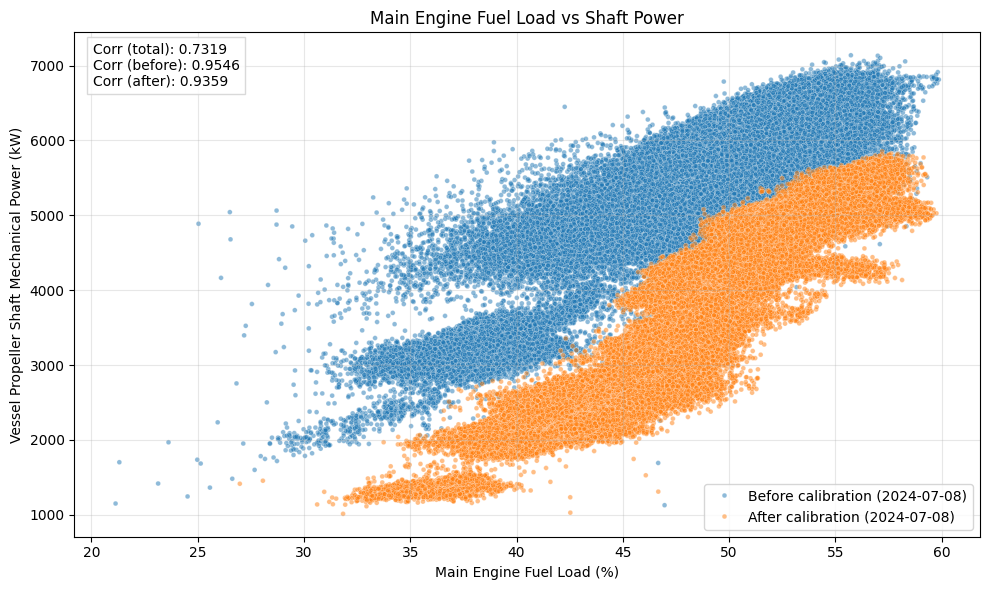

In [9]:
fig, ax, df_plot = plot_fuel_load_vs_power_by_calibration_date(df)
plt.show()

In [10]:
results = tune_k_and_torque_offset(
    df,
    k_values=[5],
    torque_offset_grid=np.arange(150),
    neighbor_agg="median",
    loss="medae",
    max_fuel_load_distance=None,
)

best_per_k = results["best_per_k"]
overall_best = results["overall_best"]

print(best_per_k)
print(overall_best)

df_corrected = apply_torque_offset_correction(
    df=df,
    torque_offset_nm=overall_best["torque_offset_nm"],
)

KeyboardInterrupt: 

C:\Users\Augus\AppData\Local\Temp\ipykernel_51180\3248562821.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


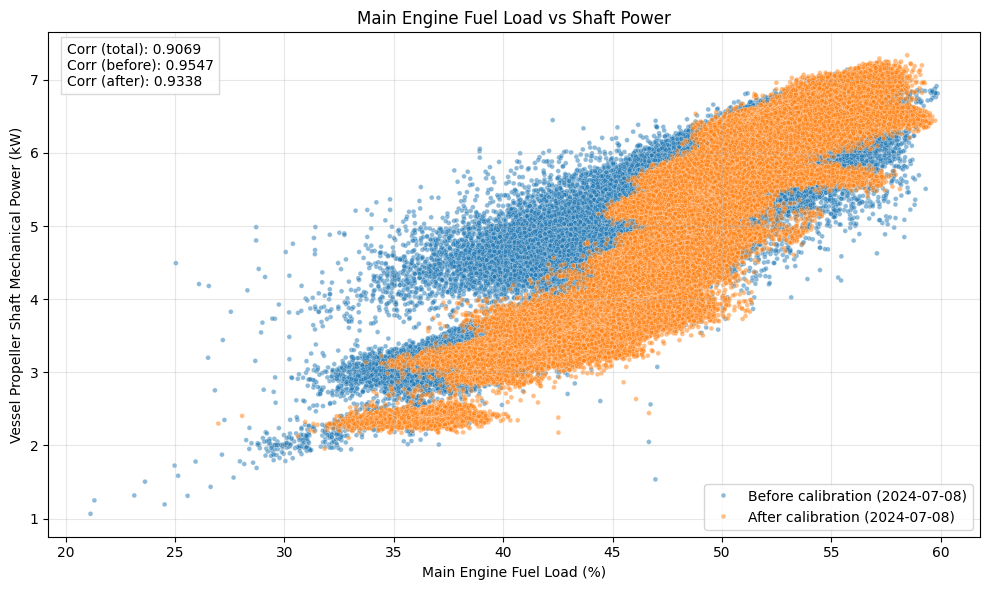

In [ ]:
fig, ax, _ = plot_fuel_load_vs_power_by_calibration_date(
    df_corrected,
    power_col="Corrected Vessel Propeller Shaft Mechanical Power (KW)",
)
plt.show()

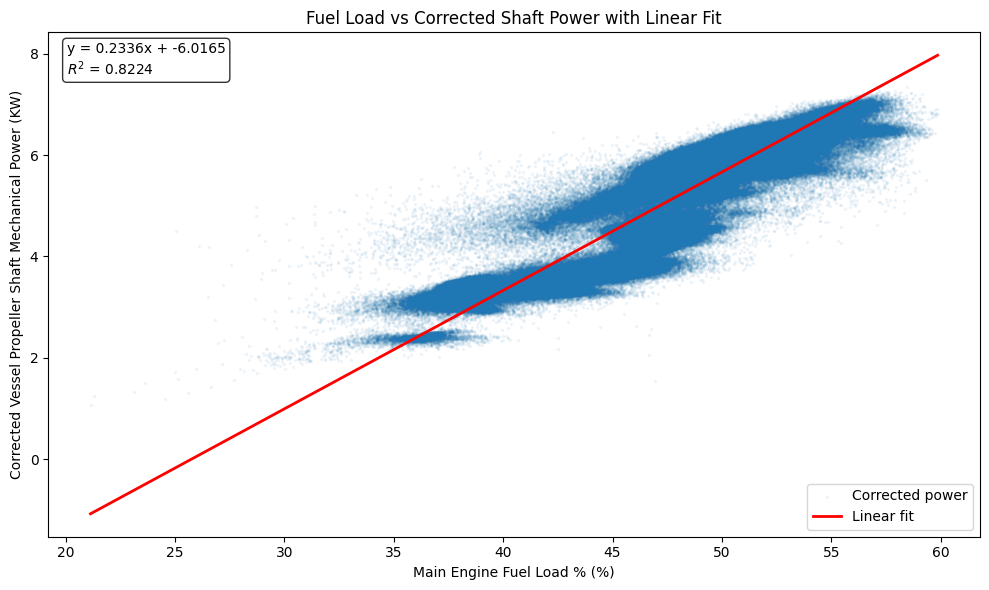

In [ ]:
# fit a line to the corrected power, shown in a scatterplot with the formula
x_col = fuel_load_col
y_col = "Corrected Vessel Propeller Shaft Mechanical Power (KW)"

fit_df = df_corrected[[x_col, y_col]].apply(pd.to_numeric, errors="coerce").dropna()
x = fit_df[x_col].to_numpy()
y = fit_df[y_col].to_numpy()

slope, intercept = np.polyfit(x, y, 1)
y_pred = slope * x + intercept
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x, y, s=2, alpha=0.05, rasterized=True, label="Corrected power")
x_line = np.linspace(x.min(), x.max(), 300)
ax.plot(x_line, slope * x_line + intercept, color="red", linewidth=2, label="Linear fit")

ax.set_title("Fuel Load vs Corrected Shaft Power with Linear Fit")
ax.set_xlabel(x_col)
ax.set_ylabel(y_col)
ax.legend()

eq_text = f"y = {slope:.4f}x + {intercept:.4f}\n$R^2$ = {r2:.4f}"
ax.text(
    0.02, 0.98, eq_text,
    transform=ax.transAxes,
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)

plt.tight_layout()
plt.show()



## 3.2. Additive approach (offset in lines)

<Axes: xlabel='Main Engine Fuel Load % (%)', ylabel='Vessel Propeller Shaft Mechanical Power (KW)'>

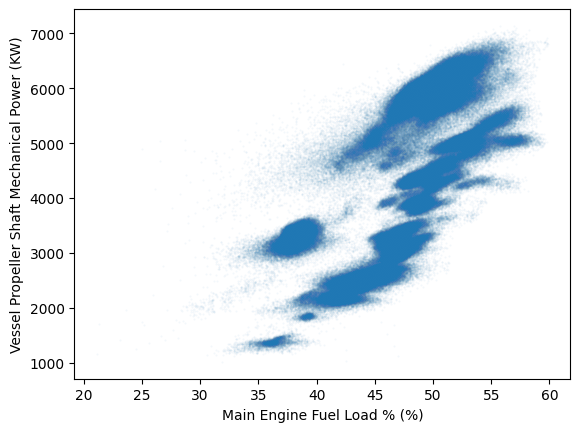

In [ ]:
# make a scatterplot of the fuel load vs power
sns.scatterplot(
    data=df_corrected,
    x=fuel_load_col,
    y=power_col,
    alpha=0.05,
    s=2,
    rasterized=True,
)

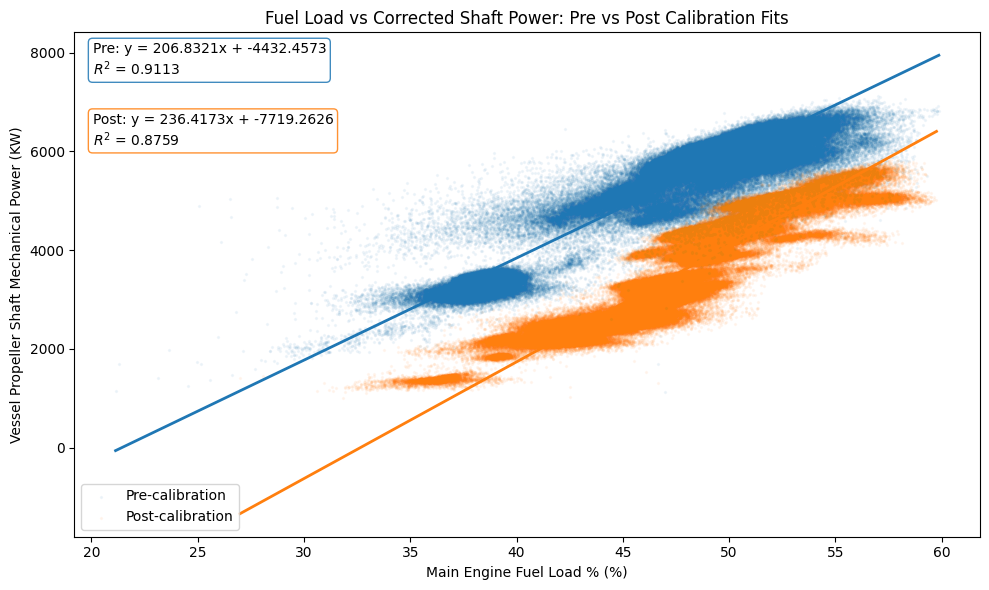

In [ ]:
# Separate linear fits for pre/post calibration on the same scatterplot
x_col = fuel_load_col
y_col = "Vessel Propeller Shaft Mechanical Power (KW)"
ts_col = "utc_timestamp"

fit_df = df[[ts_col, x_col, y_col]].copy()
fit_df[ts_col] = pd.to_datetime(fit_df[ts_col], utc=True, errors="coerce")
fit_df[x_col] = pd.to_numeric(fit_df[x_col], errors="coerce")
fit_df[y_col] = pd.to_numeric(fit_df[y_col], errors="coerce")
fit_df = fit_df.dropna(subset=[ts_col, x_col, y_col])

cal_date = pd.Timestamp(TORQUEMETER_CALIBRATION_DATE, tz="UTC")
pre_df = fit_df[fit_df[ts_col] < cal_date]
post_df = fit_df[fit_df[ts_col] >= cal_date]

# Fit lines
pre_slope, pre_intercept = np.polyfit(pre_df[x_col], pre_df[y_col], 1)
post_slope, post_intercept = np.polyfit(post_df[x_col], post_df[y_col], 1)

# R^2
pre_pred = pre_slope * pre_df[x_col].to_numpy() + pre_intercept
post_pred = post_slope * post_df[x_col].to_numpy() + post_intercept
pre_ss_res = np.sum((pre_df[y_col].to_numpy() - pre_pred) ** 2)
pre_ss_tot = np.sum((pre_df[y_col].to_numpy() - np.mean(pre_df[y_col].to_numpy())) ** 2)
post_ss_res = np.sum((post_df[y_col].to_numpy() - post_pred) ** 2)
post_ss_tot = np.sum((post_df[y_col].to_numpy() - np.mean(post_df[y_col].to_numpy())) ** 2)
pre_r2 = 1 - pre_ss_res / pre_ss_tot if pre_ss_tot > 0 else np.nan
post_r2 = 1 - post_ss_res / post_ss_tot if post_ss_tot > 0 else np.nan

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(pre_df[x_col], pre_df[y_col], s=2, alpha=0.05, color="tab:blue", label="Pre-calibration")
ax.scatter(post_df[x_col], post_df[y_col], s=2, alpha=0.05, color="tab:orange", label="Post-calibration")

x_pre_line = np.linspace(pre_df[x_col].min(), pre_df[x_col].max(), 300)
x_post_line = np.linspace(post_df[x_col].min(), post_df[x_col].max(), 300)

ax.plot(x_pre_line, pre_slope * x_pre_line + pre_intercept, color="tab:blue", linewidth=2)
ax.plot(x_post_line, post_slope * x_post_line + post_intercept, color="tab:orange", linewidth=2)

ax.set_title("Fuel Load vs Corrected Shaft Power: Pre vs Post Calibration Fits")
ax.set_xlabel(x_col)
ax.set_ylabel(y_col)
ax.legend()

pre_text = f"Pre: y = {pre_slope:.4f}x + {pre_intercept:.4f}\n$R^2$ = {pre_r2:.4f}"
post_text = f"Post: y = {post_slope:.4f}x + {post_intercept:.4f}\n$R^2$ = {post_r2:.4f}"

ax.text(
	0.02, 0.98, pre_text,
	transform=ax.transAxes, va="top",
	bbox=dict(boxstyle="round", facecolor="white", edgecolor="tab:blue", alpha=0.85)
)
ax.text(
	0.02, 0.84, post_text,
	transform=ax.transAxes, va="top",
	bbox=dict(boxstyle="round", facecolor="white", edgecolor="tab:orange", alpha=0.85)
)

plt.tight_layout()
plt.show()


Common slope: 218.073398
Pre intercept: -4965.074616
Post intercept: -6865.850418
Estimated additive post-calibration shift (kW): -1900.775802
Overall R2: 0.9455
Pre R2: 0.9086
Post R2: 0.8706


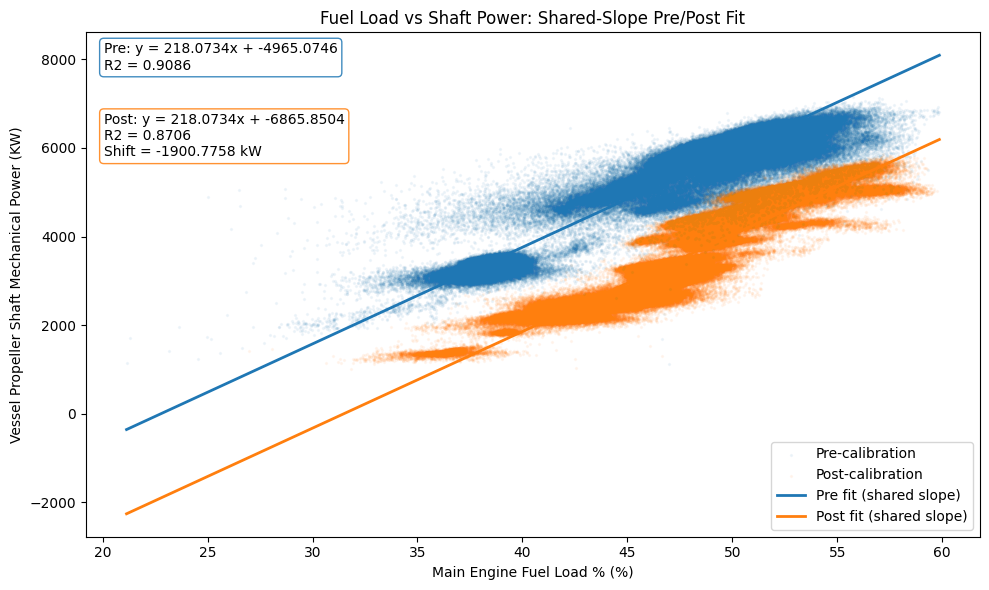

In [ ]:
# Common-slope linear fit with a post-calibration intercept shift
x_col = fuel_load_col
y_col = "Vessel Propeller Shaft Mechanical Power (KW)"
ts_col = "utc_timestamp"

fit_df = df[[ts_col, x_col, y_col]].copy()
fit_df[ts_col] = pd.to_datetime(fit_df[ts_col], utc=True, errors="coerce")
fit_df[x_col] = pd.to_numeric(fit_df[x_col], errors="coerce")
fit_df[y_col] = pd.to_numeric(fit_df[y_col], errors="coerce")
fit_df = fit_df.dropna(subset=[ts_col, x_col, y_col]).copy()

cal_date = pd.Timestamp(TORQUEMETER_CALIBRATION_DATE, tz="UTC")
fit_df["is_post"] = (fit_df[ts_col] >= cal_date).astype(int)

pre_df = fit_df[fit_df["is_post"] == 0].copy()
post_df = fit_df[fit_df["is_post"] == 1].copy()

if pre_df.empty or post_df.empty:
    raise ValueError("Need both pre- and post-calibration observations.")

# Shared-slope model:
# y = intercept_pre + common_slope * x + post_shift * is_post
X = np.column_stack([
    np.ones(len(fit_df)),
    fit_df[x_col].to_numpy(),
    fit_df["is_post"].to_numpy(),
])
y = fit_df[y_col].to_numpy()

intercept_pre, common_slope, post_shift = np.linalg.lstsq(X, y, rcond=None)[0]
intercept_post = intercept_pre + post_shift

# Predictions
pre_pred = intercept_pre + common_slope * pre_df[x_col].to_numpy()
post_pred = intercept_post + common_slope * post_df[x_col].to_numpy()
all_pred = intercept_pre + common_slope * fit_df[x_col].to_numpy() + post_shift * fit_df["is_post"].to_numpy()

# R2
pre_y = pre_df[y_col].to_numpy()
post_y = post_df[y_col].to_numpy()

pre_ss_res = np.sum((pre_y - pre_pred) ** 2)
pre_ss_tot = np.sum((pre_y - np.mean(pre_y)) ** 2)
post_ss_res = np.sum((post_y - post_pred) ** 2)
post_ss_tot = np.sum((post_y - np.mean(post_y)) ** 2)
all_ss_res = np.sum((y - all_pred) ** 2)
all_ss_tot = np.sum((y - np.mean(y)) ** 2)

pre_r2 = 1 - pre_ss_res / pre_ss_tot if pre_ss_tot > 0 else np.nan
post_r2 = 1 - post_ss_res / post_ss_tot if post_ss_tot > 0 else np.nan
overall_r2 = 1 - all_ss_res / all_ss_tot if all_ss_tot > 0 else np.nan

# This is your additive shift estimate in kW
additive_shift_kw = post_shift

# If you want to correct post-calibration observations back to the pre-calibration scale:
# corrected_post_power = observed_post_power - additive_shift_kw
fit_df["Corrected Shaft Power (KW)"] = fit_df[y_col]
fit_df.loc[fit_df["is_post"] == 1, "Corrected Shaft Power (KW)"] = (
    fit_df.loc[fit_df["is_post"] == 1, y_col] - additive_shift_kw
)

print(f"Common slope: {common_slope:.6f}")
print(f"Pre intercept: {intercept_pre:.6f}")
print(f"Post intercept: {intercept_post:.6f}")
print(f"Estimated additive post-calibration shift (kW): {additive_shift_kw:.6f}")
print(f"Overall R2: {overall_r2:.4f}")
print(f"Pre R2: {pre_r2:.4f}")
print(f"Post R2: {post_r2:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(pre_df[x_col], pre_df[y_col], s=2, alpha=0.05, color="tab:blue", label="Pre-calibration")
ax.scatter(post_df[x_col], post_df[y_col], s=2, alpha=0.05, color="tab:orange", label="Post-calibration")

x_min = fit_df[x_col].min()
x_max = fit_df[x_col].max()
x_line = np.linspace(x_min, x_max, 300)

ax.plot(
    x_line,
    intercept_pre + common_slope * x_line,
    color="tab:blue",
    linewidth=2,
    label="Pre fit (shared slope)",
)
ax.plot(
    x_line,
    intercept_post + common_slope * x_line,
    color="tab:orange",
    linewidth=2,
    label="Post fit (shared slope)",
)

ax.set_title("Fuel Load vs Shaft Power: Shared-Slope Pre/Post Fit")
ax.set_xlabel(x_col)
ax.set_ylabel(y_col)
ax.legend()

pre_text = (
    f"Pre: y = {common_slope:.4f}x + {intercept_pre:.4f}\n"
    f"R2 = {pre_r2:.4f}"
)
post_text = (
    f"Post: y = {common_slope:.4f}x + {intercept_post:.4f}\n"
    f"R2 = {post_r2:.4f}\n"
    f"Shift = {additive_shift_kw:.4f} kW"
)

ax.text(
    0.02, 0.98, pre_text,
    transform=ax.transAxes, va="top",
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="tab:blue", alpha=0.85)
)
ax.text(
    0.02, 0.84, post_text,
    transform=ax.transAxes, va="top",
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="tab:orange", alpha=0.85)
)

plt.tight_layout()
plt.show()

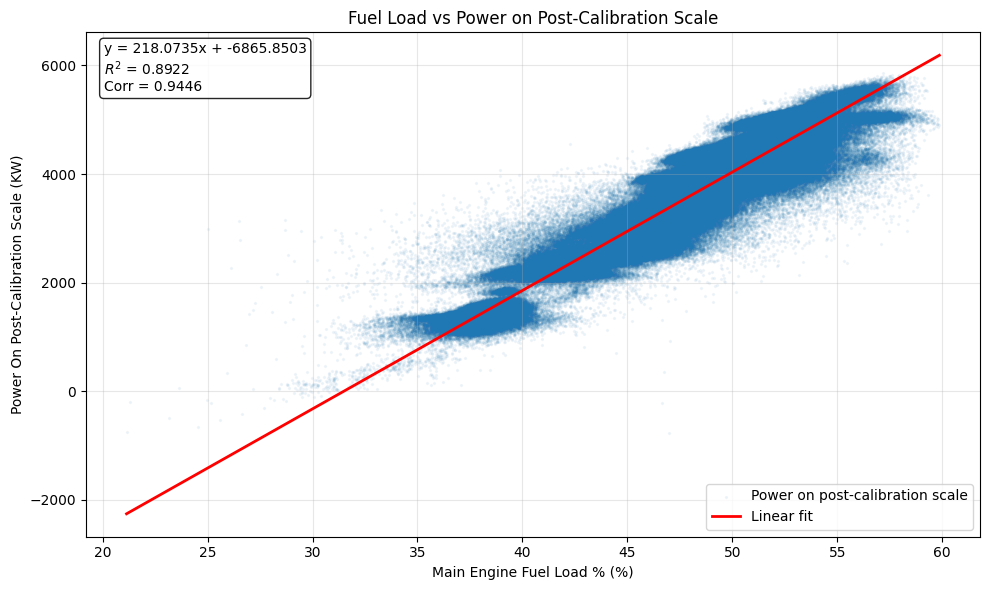

Applied additive correction of +-1900.77 kW to pre-calibration rows.


In [29]:
# Move everything to the post-calibration scale:
# shift pre-calibration observations by the estimated additive offset.
additive_shift_kw = -1900.77

x_col = fuel_load_col
y_col = "Vessel Propeller Shaft Mechanical Power (KW)"
ts_col = "utc_timestamp"
corr_col = "Power On Post-Calibration Scale (KW)"

corr_df = df[[ts_col, x_col, y_col]].copy()
corr_df[ts_col] = pd.to_datetime(corr_df[ts_col], utc=True, errors="coerce")
corr_df[x_col] = pd.to_numeric(corr_df[x_col], errors="coerce")
corr_df[y_col] = pd.to_numeric(corr_df[y_col], errors="coerce")
corr_df = corr_df.dropna(subset=[ts_col, x_col, y_col]).copy()

cal_date = pd.Timestamp(TORQUEMETER_CALIBRATION_DATE, tz="UTC")
pre_mask = corr_df[ts_col] < cal_date

corr_df[corr_col] = corr_df[y_col]
corr_df.loc[pre_mask, corr_col] = corr_df.loc[pre_mask, y_col] + additive_shift_kw

fit_df = corr_df[[x_col, corr_col]].dropna().copy()
x = fit_df[x_col].to_numpy()
y = fit_df[corr_col].to_numpy()

slope, intercept = np.polyfit(x, y, 1)
y_pred = slope * x + intercept
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
correlation = np.corrcoef(x, y)[0, 1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x, y, s=2, alpha=0.05, rasterized=True, label="Power on post-calibration scale")

x_line = np.linspace(x.min(), x.max(), 300)
ax.plot(x_line, slope * x_line + intercept, color="red", linewidth=2, label="Linear fit")

ax.set_title("Fuel Load vs Power on Post-Calibration Scale")
ax.set_xlabel(x_col)
ax.set_ylabel(corr_col)
ax.legend()
ax.grid(True, alpha=0.3)

eq_text = f"y = {slope:.4f}x + {intercept:.4f}\n$R^2$ = {r2:.4f}\nCorr = {correlation:.4f}"
ax.text(
    0.02, 0.98, eq_text,
    transform=ax.transAxes,
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
)

plt.tight_layout()
plt.show()

print(f"Applied additive correction of +{additive_shift_kw:.2f} kW to pre-calibration rows.")

# 4. Weather plausibility

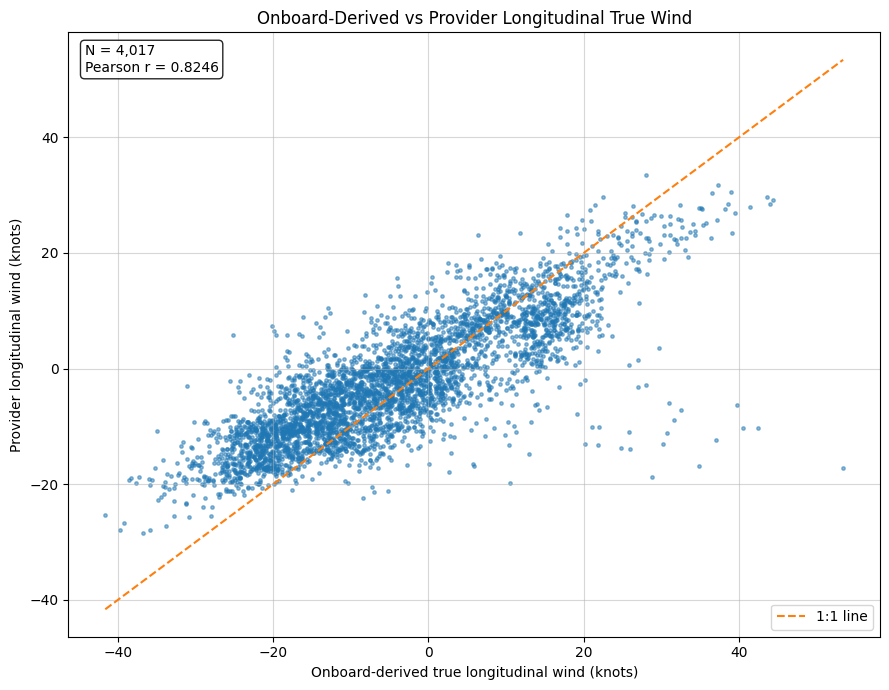

Selected columns:
  rel_speed_col:       Vessel External Conditions Wind Relative Speed (knots)
  rel_angle_col:       Vessel External Conditions Wind Relative Angle (degrees)
  sog_col:             Vessel Hull Over Ground Speed (knots)
  heading_col:         Vessel Hull Heading True Angle (degrees)
  provider_east_col:   Vessel External Conditions Eastward Wind Velocity (Provider S)
  provider_north_col:  Vessel External Conditions Northward Wind Velocity (Provider S)

Derived columns created:
  provider_longitudinal_wind
  anemometer_apparent_longitudinal
  anemometer_true_longitudinal

Rows used in plot: 4,017
Pearson correlation: 0.8246


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Scatterplot: onboard-derived true longitudinal wind
#            vs provider longitudinal wind
# ============================================================

rel_speed_col = "Vessel External Conditions Wind Relative Speed (knots)"
rel_angle_col = "Vessel External Conditions Wind Relative Angle (degrees)"
sog_col = "Vessel Hull Over Ground Speed (knots)"
heading_col = "Vessel Hull Heading True Angle (degrees)"
provider_east_col = "Vessel External Conditions Eastward Wind Velocity (Provider S)"
provider_north_col = "Vessel External Conditions Northward Wind Velocity (Provider S)"

required_cols = [
    rel_speed_col,
    rel_angle_col,
    sog_col,
    heading_col,
    provider_east_col,
    provider_north_col,
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

plot_df = df[required_cols].copy()
for c in required_cols:
    plot_df[c] = pd.to_numeric(plot_df[c], errors="coerce")

# ------------------------------------------------------------
# Unit conversion: provider east/north wind is in m/s, convert to knots
# ------------------------------------------------------------
MS_TO_KNOTS = 1.94384449
plot_df["provider_east_knots"] = plot_df[provider_east_col] * MS_TO_KNOTS
plot_df["provider_north_knots"] = plot_df[provider_north_col] * MS_TO_KNOTS

# ------------------------------------------------------------
# Provider longitudinal wind component
# Positive = wind blowing in vessel forward direction (tailwind component)
# Negative = wind blowing against vessel forward direction (headwind component)
# ------------------------------------------------------------
heading_rad = np.deg2rad(plot_df[heading_col])

forward_east = np.sin(heading_rad)
forward_north = np.cos(heading_rad)

plot_df["provider_longitudinal_wind"] = (
    plot_df["provider_east_knots"] * forward_east
    + plot_df["provider_north_knots"] * forward_north
)

# ------------------------------------------------------------
# Onboard apparent longitudinal wind from anemometer
#
# Assumption:
# - relative angle is a "wind coming from" angle relative to bow
# - 0 deg means wind coming from straight ahead
#
# Under that convention:
# apparent longitudinal component = - rel_speed * cos(relative_angle)
# so:
#   angle = 0 deg   -> strong headwind apparent component (negative)
#   angle = 180 deg -> tailwind apparent component (positive)
# ------------------------------------------------------------
rel_angle_rad = np.deg2rad(plot_df[rel_angle_col])

plot_df["anemometer_apparent_longitudinal"] = (
    -plot_df[rel_speed_col] * np.cos(rel_angle_rad)
)

# ------------------------------------------------------------
# Convert apparent longitudinal wind to true longitudinal wind
# using vessel speed over ground
#
# true_wind = apparent_wind + ship_velocity   (in consistent coordinates)
# ------------------------------------------------------------
plot_df["anemometer_true_longitudinal"] = (
    plot_df["anemometer_apparent_longitudinal"] + plot_df[sog_col]
)

# ------------------------------------------------------------
# Keep valid rows only
# ------------------------------------------------------------
plot_df = plot_df.dropna(
    subset=[
        "anemometer_true_longitudinal",
        "provider_longitudinal_wind",
    ]
)

if plot_df.empty:
    raise ValueError("No valid rows after constructing longitudinal wind components.")

x = plot_df["anemometer_true_longitudinal"].to_numpy()
y = plot_df["provider_longitudinal_wind"].to_numpy()

corr = float(np.corrcoef(x, y)[0, 1]) if len(plot_df) > 1 else np.nan

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter(
    x,
    y,
    s=6,
    alpha=0.5,
    color="tab:blue",
    rasterized=True,
)

xy_min = float(np.nanmin([np.nanmin(x), np.nanmin(y)]))
xy_max = float(np.nanmax([np.nanmax(x), np.nanmax(y)]))

ax.plot(
    [xy_min, xy_max],
    [xy_min, xy_max],
    linestyle="--",
    linewidth=1.5,
    color="tab:orange",
    label="1:1 line",
)

ax.set_title("Onboard-Derived vs Provider Longitudinal True Wind")
ax.set_xlabel("Onboard-derived true longitudinal wind (knots)")
ax.set_ylabel("Provider longitudinal wind (knots)")
ax.grid(True, alpha=0.5)
ax.legend()

ax.text(
    0.02,
    0.98,
    f"N = {len(plot_df):,}\nPearson r = {corr:.4f}",
    transform=ax.transAxes,
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Optional quick diagnostics
# ------------------------------------------------------------
print("Selected columns:")
print(f"  rel_speed_col:       {rel_speed_col}")
print(f"  rel_angle_col:       {rel_angle_col}")
print(f"  sog_col:             {sog_col}")
print(f"  heading_col:         {heading_col}")
print(f"  provider_east_col:   {provider_east_col}")
print(f"  provider_north_col:  {provider_north_col}")
print()
print("Derived columns created:")
print("  provider_longitudinal_wind")
print("  anemometer_apparent_longitudinal")
print("  anemometer_true_longitudinal")
print()
print(f"Rows used in plot: {len(plot_df):,}")
print(f"Pearson correlation: {corr:.4f}")

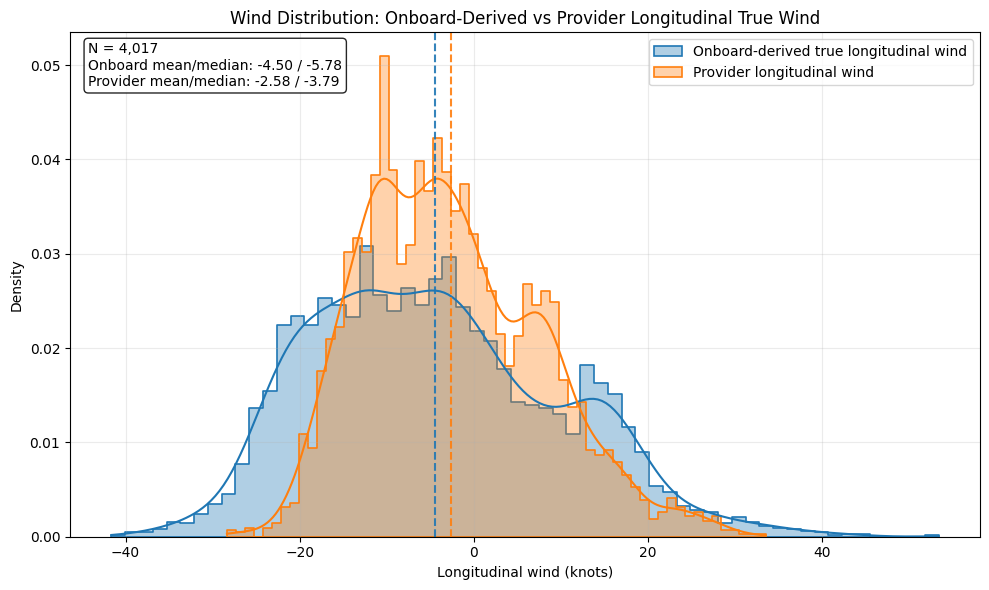

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Overlaid histograms:
# onboard-derived true longitudinal wind vs provider longitudinal wind
# ============================================================

rel_speed_col = "Vessel External Conditions Wind Relative Speed (knots)"
rel_angle_col = "Vessel External Conditions Wind Relative Angle (degrees)"
sog_col = "Vessel Hull Over Ground Speed (knots)"
heading_col = "Vessel Hull Heading True Angle (degrees)"
provider_east_col = "Vessel External Conditions Eastward Wind Velocity (Provider S)"
provider_north_col = "Vessel External Conditions Northward Wind Velocity (Provider S)"

required_cols = [
    rel_speed_col,
    rel_angle_col,
    sog_col,
    heading_col,
    provider_east_col,
    provider_north_col,
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

plot_df = df[required_cols].copy()
for c in required_cols:
    plot_df[c] = pd.to_numeric(plot_df[c], errors="coerce")

# ------------------------------------------------------------
# Convert provider wind from m/s to knots so both signals use same unit
# ------------------------------------------------------------
MS_TO_KNOTS = 1.94384449
plot_df["provider_east_knots"] = plot_df[provider_east_col] * MS_TO_KNOTS
plot_df["provider_north_knots"] = plot_df[provider_north_col] * MS_TO_KNOTS

# ------------------------------------------------------------
# Provider longitudinal wind component
# Positive = blowing in vessel forward direction
# Negative = blowing against vessel forward direction
# ------------------------------------------------------------
heading_rad = np.deg2rad(plot_df[heading_col])
forward_east = np.sin(heading_rad)
forward_north = np.cos(heading_rad)

plot_df["provider_longitudinal_wind"] = (
    plot_df["provider_east_knots"] * forward_east
    + plot_df["provider_north_knots"] * forward_north
)

# ------------------------------------------------------------
# Onboard apparent longitudinal wind from relative speed + relative angle
# Assumption: relative angle is a "wind coming from" angle relative to bow
# ------------------------------------------------------------
rel_angle_rad = np.deg2rad(plot_df[rel_angle_col])

plot_df["anemometer_apparent_longitudinal"] = (
    -plot_df[rel_speed_col] * np.cos(rel_angle_rad)
)

# ------------------------------------------------------------
# Convert apparent longitudinal wind to true longitudinal wind
# ------------------------------------------------------------
plot_df["anemometer_true_longitudinal"] = (
    plot_df["anemometer_apparent_longitudinal"] + plot_df[sog_col]
)

# ------------------------------------------------------------
# Keep valid rows only
# ------------------------------------------------------------
plot_df = plot_df.dropna(
    subset=[
        "anemometer_true_longitudinal",
        "provider_longitudinal_wind",
    ]
)

if plot_df.empty:
    raise ValueError("No valid rows after constructing longitudinal wind components.")

# ------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------
anemo_mean = float(plot_df["anemometer_true_longitudinal"].mean())
provider_mean = float(plot_df["provider_longitudinal_wind"].mean())

anemo_median = float(plot_df["anemometer_true_longitudinal"].median())
provider_median = float(plot_df["provider_longitudinal_wind"].median())

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    plot_df["anemometer_true_longitudinal"],
    bins=60,
    stat="density",
    element="step",
    fill=True,
    alpha=0.35,
    color="tab:blue",
    label="Onboard-derived true longitudinal wind",
    ax=ax,
    kde=True,
    linewidth=1.2,
)

sns.histplot(
    plot_df["provider_longitudinal_wind"],
    bins=60,
    stat="density",
    element="step",
    fill=True,
    alpha=0.35,
    color="tab:orange",
    label="Provider longitudinal wind",
    ax=ax,
    kde=True,
    linewidth=1.2,
)

ax.axvline(anemo_mean, color="tab:blue", linestyle="--", linewidth=1.5, alpha=0.9)
ax.axvline(provider_mean, color="tab:orange", linestyle="--", linewidth=1.5, alpha=0.9)

ax.set_title("Wind Distribution: Onboard-Derived vs Provider Longitudinal True Wind")
ax.set_xlabel("Longitudinal wind (knots)")
ax.set_ylabel("Density")
ax.grid(True, alpha=0.25)
ax.legend()

stats_text = (
    f"N = {len(plot_df):,}\n"
    f"Onboard mean/median: {anemo_mean:.2f} / {anemo_median:.2f}\n"
    f"Provider mean/median: {provider_mean:.2f} / {provider_median:.2f}"
)

ax.text(
    0.02,
    0.98,
    stats_text,
    transform=ax.transAxes,
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
)

plt.tight_layout()
plt.show()

# 5. Power / Torque correlation


In [19]:
# add a column that calculates the power from torque and propeller rpm, then plot it against the observed power column

# Make a second version of the graph where it is colored by pre- and post-calibration

# 6. Dummy speed-power curves

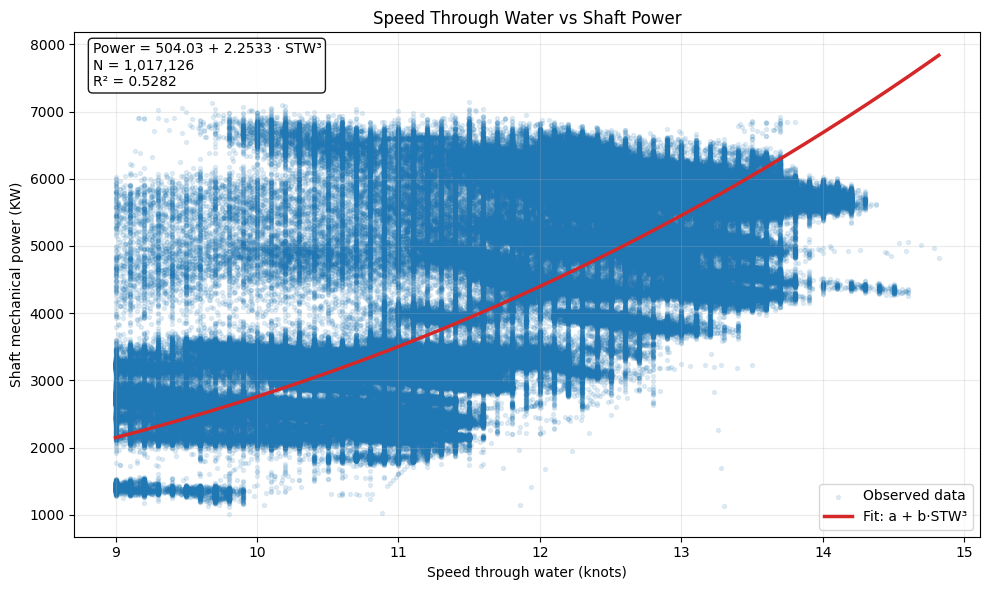

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Scatterplot of STW vs shaft power
# with fitted line based on Power = a + b * STW^3
# ============================================================

x_col = "Vessel Hull Through Water Longitudinal Speed (knots)"
y_col = "Vessel Propeller Shaft Mechanical Power (KW)"

required_cols = [x_col, y_col]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

plot_df = df[[x_col, y_col]].copy()
plot_df[x_col] = pd.to_numeric(plot_df[x_col], errors="coerce")
plot_df[y_col] = pd.to_numeric(plot_df[y_col], errors="coerce")

plot_df = plot_df.dropna(subset=[x_col, y_col])
plot_df = plot_df[(plot_df[x_col] > 0) & (plot_df[y_col] > 0)]

if len(plot_df) < 10:
    raise ValueError("Not enough valid rows to fit the relationship.")

x = plot_df[x_col].to_numpy()
y = plot_df[y_col].to_numpy()

x_cubed = x**3

# Linear fit in transformed space: y = a + b * x^3
b, a = np.polyfit(x_cubed, y, deg=1)

x_line = np.linspace(x.min(), x.max(), 400)
y_line = a + b * (x_line**3)

# R^2
y_pred = a + b * x_cubed
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

eq_text = (
    f"Power = {a:.2f} + {b:.4f} · STW³\n"
    f"N = {len(plot_df):,}\n"
    f"R² = {r2:.4f}"
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    x,
    y,
    s=8,
    alpha=0.12,
    color="tab:blue",
    rasterized=True,
    label="Observed data"
)

ax.plot(
    x_line,
    y_line,
    color="tab:red",
    linewidth=2.5,
    label="Fit: a + b·STW³"
)

ax.set_title("Speed Through Water vs Shaft Power")
ax.set_xlabel("Speed through water (knots)")
ax.set_ylabel("Shaft mechanical power (KW)")
ax.grid(True, alpha=0.25)
ax.legend()

ax.text(
    0.02,
    0.98,
    eq_text,
    transform=ax.transAxes,
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)

plt.tight_layout()
plt.show()